Notebook for reading and computing TFM coefficients for testfield_z like setup from Astaroth standalone
-----------------------------------------------------------------------------------

Creating output directory at output
nz,nzz= 512 401
alp11,alp22,eta11,eta22= -0.014547481910103239 -0.014999475224060137 0.01573959942562056 0.015544460523881686
avurms= 0.07617240538653365
Helicity 0.009537464985162095


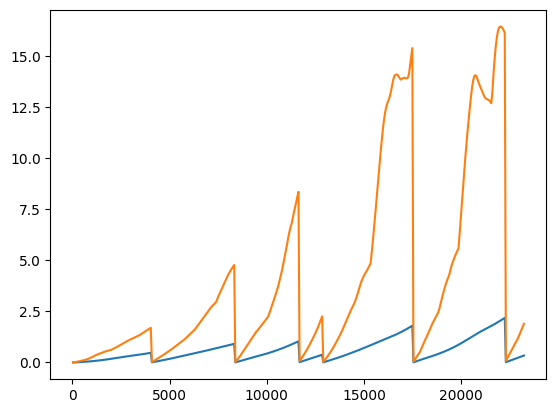

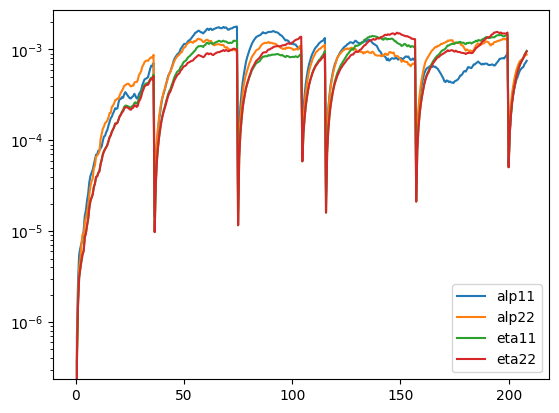

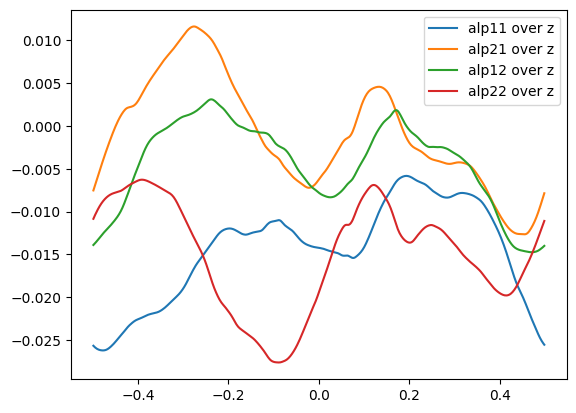

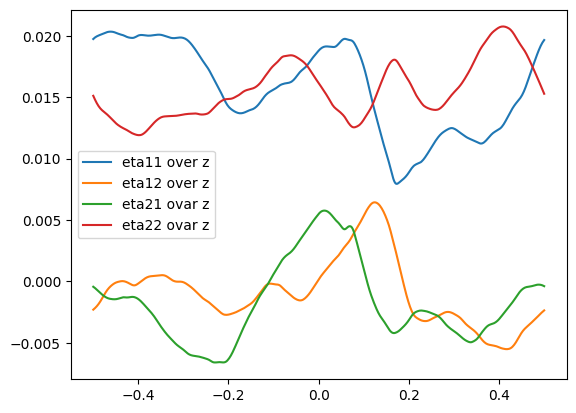

In [1]:
import os
#This script needs to be copied to your run directory, path below.
os.chdir("/scratch/project_462001062/mkorpi/tfm/pmdep/pm5_kf1/")
#Reading with construct_coeffs.py contained in Astaroth Bitbucket tfm branch
#Path to the script is specified below, most likely in some projappl dir.
%run /projappl/project_462001062/mkorpi/astaroth/samples/tfm-mpi/construct_coeffs.py --dims 512 512 512 --inputs *.profile

In [2]:
#Currently you still need to output these from mhd.ini [in your run directory] by hand
nu=0.0005
eta=0.0001
eta_tfm=0.0001
kf=1.5
roberts_flow=0
if roberts_flow :
    u0=1.0
    kf=np.sqrt(2.0)
    alp0=-1.0/2.0*u0
    eta0=1./2.*u0/kf
    rm=u0/eta/kf
    re=u0/nu/kf
else:
    alp0=-avurms/3.0
    eta0=avurms/3.0/kf
    rm=avurms/eta/kf
    re=avurms/nu/kf
    pm=rm/re
print("alp0",alp0)
print("eta0",eta0)
print("kf",kf)
print("rm,re,pm",rm,re,pm)
print("T,nzz",np.max(tt),nzz)

alp0 -0.025390801795511217
eta0 0.01692720119700748
kf 1.5
rm,re,pm 507.81603591022434 101.56320718204488 5.0
T,nzz 208.3078 401


In [3]:
import numpy as np

def clean_timeseries(
    y,
    drop_threshold=0.5,
    recovery_points=20,
    warmup_points=40
):
    y = np.asarray(y)

    # detect drops
    dy = np.diff(y, prepend=y[0])
    reset_idx = dy < -drop_threshold * np.nanmax(y)

    # build mask (True = keep)
    mask = np.ones_like(y, dtype=bool)

    # exclude warmup region
    mask[:warmup_points] = False

    # exclude resets + recovery
    for i in np.where(reset_idx)[0]:
        end = min(i + recovery_points, len(y))
        mask[i:end] = False

    # compute stats
    clean = y[mask]

    mean = np.mean(clean)
    std = np.std(clean)

    # --- uncertainty from 3 subintervals ---
    n = len(clean)
    thirds = np.array_split(clean, 3)

    sub_means = [np.mean(part) for part in thirds]

    uncertainty = np.max(np.abs(sub_means - mean))

    return mean, std, uncertainty, mask


In [4]:
#Old statistics as in emfs.ipynb
print(np.shape(alp11zt))
print(np.shape(ttt))
start=40
end=400
ntt=end-start
print(np.sum(alp11zt[start:end,:])/nz/ntt/alp0)
print(np.sum(alp22zt[start:end,:])/nz/ntt/alp0)
print(np.sum(eta11zt[start:end,:])/nz/ntt/eta0)
print(np.sum(eta22zt[start:end,:])/nz/ntt/eta0)


(401, 512)
(401,)
0.6276949266378309
0.6459121017660304
1.0235779966409204
1.0109641121635926


In [5]:
#Refine the parameters in this section.
t = np.asarray(ttt)
y = np.asarray(eta22t).ravel()
th=0.2
recp=30
wup=80
mean, std, u, mask = clean_timeseries(np.asarray(alp11t).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)

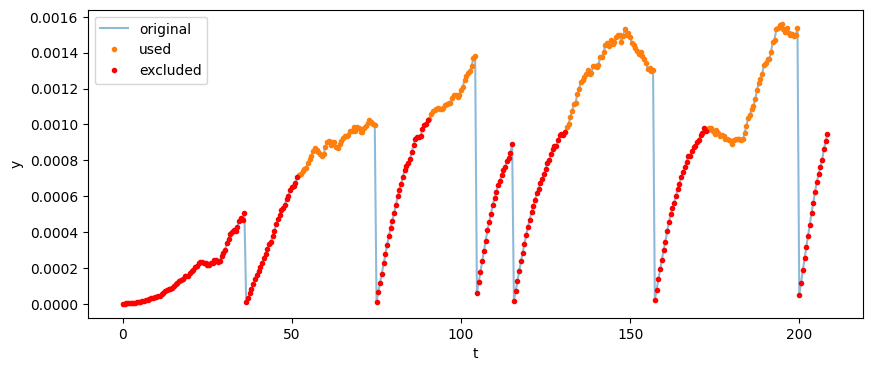

In [6]:
plt.figure(figsize=(10,4))

# original
plt.plot(t, y, label="original", alpha=0.5)

# kept data
plt.plot(t[mask], y[mask], ".", label="used")

# excluded data
plt.plot(t[~mask], y[~mask], ".", label="excluded", color="red")

plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.show()

In [7]:
#New statistics
t = np.asarray(ttt)
th=0.2
recp=30
wup=80
alp11tt=np.sum(alp11zt,axis=1)/nz/alp0
meana11, stda11, ua11, maska11 = clean_timeseries(np.asarray(alp11tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp22tt=np.sum(alp22zt,axis=1)/nz/alp0
meana22, stda22, ua22, maska22 = clean_timeseries(np.asarray(alp22tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp12tt=np.sum(alp12zt,axis=1)/nz/alp0
meana12, stda12, ua12, maska12 = clean_timeseries(np.asarray(alp12tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
alp21tt=np.sum(alp21zt,axis=1)/nz/alp0
meana21, stda21, ua21, maska21 = clean_timeseries(np.asarray(alp21tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta11tt=np.sum(eta11zt,axis=1)/nz/eta0
meane11, stde11, ue11, maske11 = clean_timeseries(np.asarray(eta11tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta22tt=np.sum(eta22zt,axis=1)/nz/eta0
meane22, stde22, ue22, maske22 = clean_timeseries(np.asarray(eta22tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta12tt=np.sum(eta12zt,axis=1)/nz/eta0
meane12, stde12, ue12, maske12 = clean_timeseries(np.asarray(eta12tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
eta21tt=np.sum(eta21zt,axis=1)/nz/eta0
meane21, stde21, ue21, maske21 = clean_timeseries(np.asarray(eta21tt).ravel(),
                    drop_threshold=th,recovery_points=recp,warmup_points=wup)
print(meana11,ua11,stda11)
print(meana22,ua22,stda22)
print(meana12,ua12,stda12)
print(meana21,ua21,stda21)
print(meane11,ue11,stde11)
print(meane22,ue22,stde22)
print(meane12,ue12,stde12)
print(meane21,ue21,stde21)

0.6371003763536529 0.5831699815200744 0.47791250460502127
0.7182424252631296 0.20110665714718612 0.2143756753263862
0.21395539278825493 0.28699392100437604 0.23111261391765628
-0.01669952950846754 0.1500579302456688 0.25138136911958253
1.3957957272731059 0.11147461238070422 0.23219130960878623
1.3987595196010156 0.23947806538080085 0.270955828897143
-0.03714516485468636 0.10005390605661124 0.13554831868165562
-0.020942480962990798 0.08514868502924311 0.09935324285255617


In [8]:
#Writing to a csv file
import pandas as pd
from pathlib import Path

def append_result(filename, result_dict):
    df = pd.DataFrame([result_dict])

    file_exists = Path(filename).exists()

    df.to_csv(
        filename,
        mode="a",
        header=not file_exists,
        index=False
    )

In [11]:
run_id='pm5_kf1'
res="512 cubed"
malpn=(meana11+meana22)/2.
metan=(meane11+meane22)/2.
umalpn=(ua11+ua22)/2.
umetan=(ue11+ue22)/2.
malpu=malpn*alp0
metau=metan*eta0
etatot=eta+metau
append_result("/scratch/project_462001062/mkorpi/tfm/pmdep/results.csv", {
    "run": run_id,
    "res": res,
    "Warmup": wup,
    "Thresh": th,
    "Recovery points": recp,
    "nu": nu,
    "eta": eta,
    "kf": kf,
    "pm": pm,
    "Rm": rm,
    "Re": re,
    "urms": avurms,
    "alp/alp0": malpn,
    "alp": malpu,
    "ac alp/alp0": umalpn, 
    "eta/eta0": metan,
    "eta": metau,
    "eta_T": etatot,
    "ac eta/eta0": umetan,
    "Mask points": mask.sum()
})